# TN2211 Session 5

## Instruments

In [100]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt
import math
from scipy.signal import hilbert
import numpy as np

In [96]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR')

In [97]:
scope = Scope("SDS")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR
Setting memory depth to 10k points


In [98]:
gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR


## Calculator 

It is always handy to have some code cells to do quick calculations for you. 

In [12]:
R = 1e3 # Ohms
C = 10e-9 # Farads

w_c = 1/R/C
f_c = w_c / 2 / np.pi

print("Corner frequency: %.2e Hz" % f_c)

Corner frequency: 1.59e+04 Hz


In [ ]:
# add cells as needed for your calculations

In [ ]:
# more calculations

## Step-function time traces

First, define some functions for what the step response transient could *theoretically* look like. 

Specifically, the most arbitrary step response will have this form:

$$
f(t) = [a e^{-(t-d)/b)} \cos(c (t-d) + e)  + f ]\ \theta(t-d) + g
$$

The parameters are: 

* $a$: The amplitude of the oscillating, decaying signal
* $b$: The decay time ([1/e time](https://en.wikipedia.org/wiki/Time_constant)) of the decay of the envelope of the oscillation
* $c$: The angular frequency of the oscillation
* $d$: The time $t_0$ that the step function and the oscillation starts
* $e$: The phase $\phi$ of the oscillating signal in radians, aligned to a cosine that starts with $t_0 = d$
* $f$: A possible step offset of the DC value after the step response
* $g$: A possible offset of the DC value before the pulse starts

The function $\theta(t)$ is a step function (formally a [Heavyside step function](https://en.wikipedia.org/wiki/Heaviside_step_function) that has the value 0 for $t<0$ and 1 for $t>0$. 

Let's make some plots of what this function looks like:


In [139]:
# The decaying oscillation
def func(t, a, b, c, d, e, f, g):
    return (t > d) * ( a*np.exp(-(t-d)/b)*np.cos(c*(t-d) + e) + f) + g

# The envelope, handy to also plot 
def func2(t, a, b, c, d, e, f, g):
    return (t > d) * ( a*np.exp(-(t-d)/b) + f) + g


Before we start fitting, it is useful to make some plots of the function to understand what it looks like in general and how the parameters of the function change it's shape. 

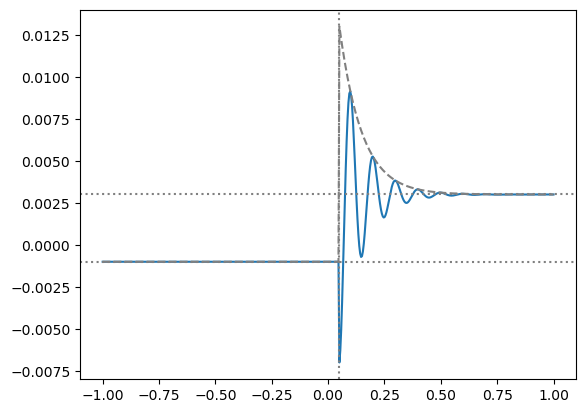

In [153]:
t = np.linspace(-1,1, 500)

# The parameters. If you understand what they physically represent in terms of the shape of the 
# function, you can already make a good estimate of what they will be from your measured trace. 

a = 10e-3# amplitude of the oscillating signal, estimated for example on the scope
b = 100e-3 # decay time in s
c = 2*np.pi * 5e3 # 5 kHz = 2 pi * 5e3 Radians/sec
d = 50e-3 # t0, the time that the step function starts, and also the time that cosine starts, in ms
e = 0 # phase in radians, 0 = cosine starting at t0
f = 4e-3 # step of the offset voltage 
g = -1e-3 # offset voltage before the step

y1 = func(t,a,b,c,d,e,f,g)

plt.plot(t,y1)
plt.plot(t,func2(t,a,b,c,d,e,f,g), c='gray', ls="--")
plt.axhline(g, ls=":", c='gray') # DC offset before the pulse
plt.axhline(g+f, ls=":", c='gray') # DC offset after the pulse
plt.axvline(d, ls=":", c="gray") # the the time offset

We can also see what what it looks like if we use a phase of $\pi/2$ to get a sine wave:

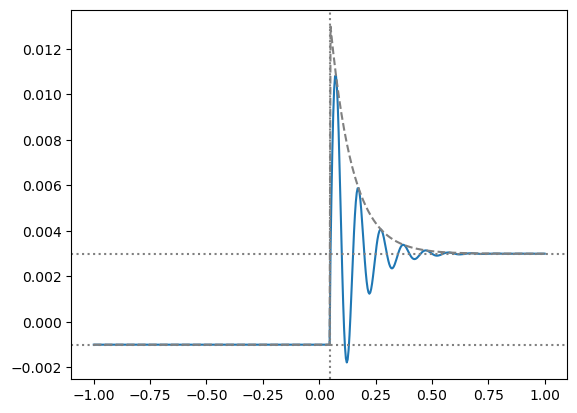

In [155]:
e = np.pi/2 # phase in radians, 0 = cosine starting at t0

y1 = func(t,a,b,c,d,e,f,g)

plt.plot(t,y1)
plt.plot(t,func2(t,a,b,c,d,e,f,g), c='gray', ls="--")
plt.axhline(g, ls=":", c='gray') # DC offset before the pulse
plt.axhline(g+f, ls=":", c='gray') # DC offset after the pulse
plt.axvline(d, ls=":", c="gray") # the the time offset

Now, we can get data from our scope!

In [159]:
# Data that Gary measured

# t, v = np.loadtxt("2025-12-10/scope_trace_2025-12-10-09.25.31.dat", unpack=True)

In [102]:
# your own data
t,v = scope.get_trace(1)

Retreiving 10000 points


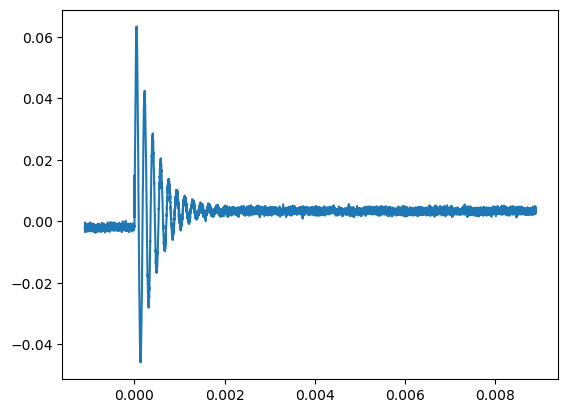

In [160]:
plt.plot(t,v)

First step: plot what you expect theoretically on top of the data, based on the formulas from class that tell you the resonance frequency and the decay time. For a parallel RLC, we have:

$$
\omega = \frac{1}{\sqrt{LC}}
$$
$$
Q_{parallel} = \omega RC
$$
$$
\tau = \frac{Q}{\omega} = \frac{\omega L }{R}
$$

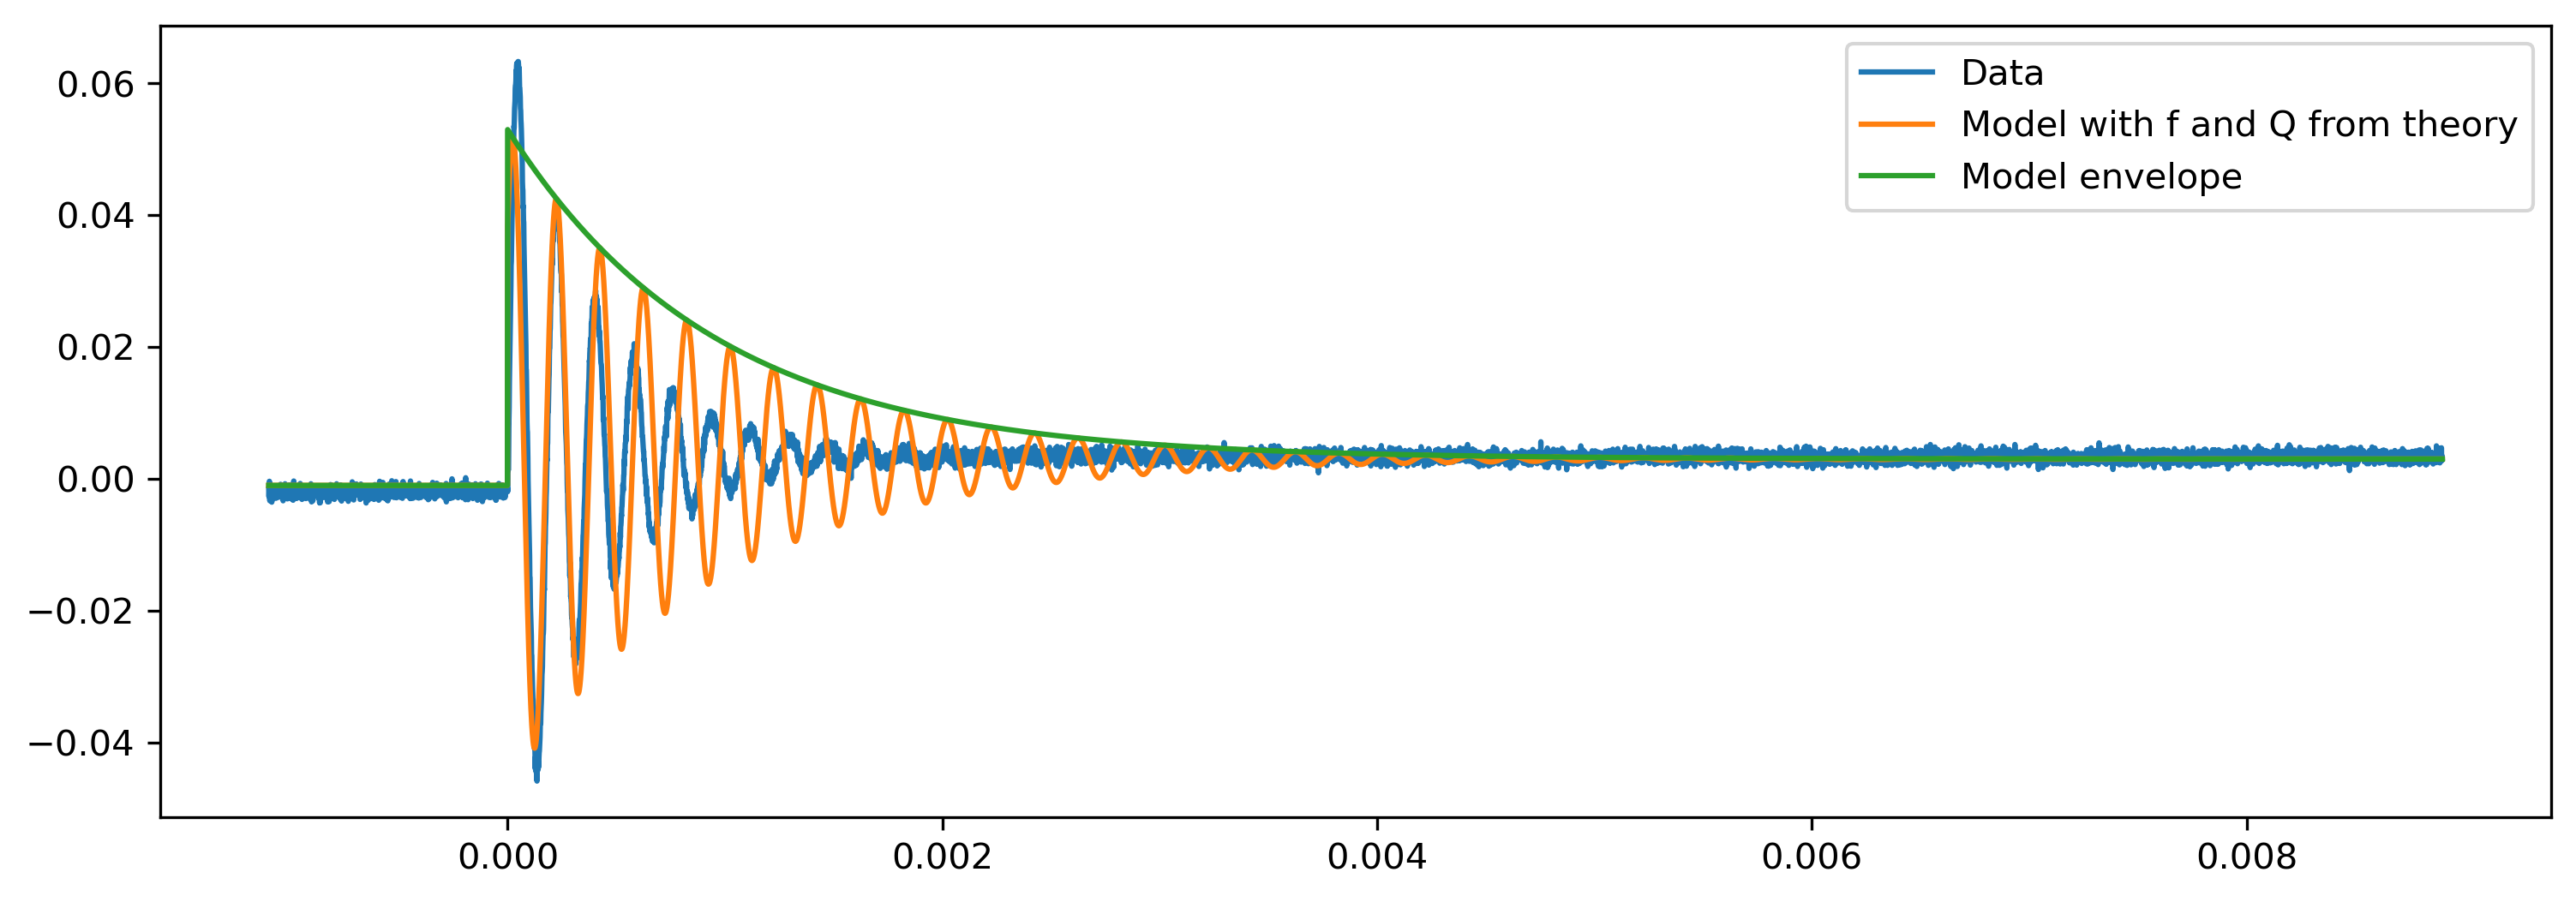

In [171]:
f = 5e3

# guess based on the plot
a = 50e-3 # amplitude of the oscillating signal, estimated for example on the scope

c = 2*np.pi * 5e3 # 5 kHz = 2 pi * 5e3 Radians/sec, from my formula estimates in the homework

# I can calculate tau from Q and omega
Q = 30 # from my formula estimates in the prep work
b = Q/c # decay time in s

# looks pretty close to zero
d = 0 # t0, the time that the step function starts, and also the time that cosine starts, in ms

# Looks like a sine function, so pi/4
e = -np.pi/4 # phase in radians, 0 = cosine starting at t0

# Looks like there is about 10 mv offset before the step
f = 4e-3 # step of the offset voltage 

# and maybe 20 mV step up after the step? 
g = -1e-3 # offset voltage before the step

# Make it wider and higher res
plt.figure(figsize=(12,4), dpi=300) 
plt.plot(t,v, label = "Data")
plt.plot(t,func(t,a,b,c,d,e,f,g), label = "Model with f and Q from theory")
plt.plot(t,func2(t,a,b,c,d,e,f,g), label = "Model envelope")
plt.legend()

Next step is to play around with the parameters to get something that matches as close as you can to the experimental data. 

Once the data matches the model "pretty well by hand tweaking", you have already an excellent estimate of the experimentally determined parameters of your circuit. 

If you want to know what the best possible estimate is, along with the errorbars on your parameters, you can also fit this using `curve_fit` from scipy, or if you want more power and control, you can also use [lmfit](https://lmfit.github.io/lmfit-py/).

## Frequency sweep traces

Some code to help set up and analyze "chirp" frequency sweeps.

In [72]:
def setup_frequency_sweep(start_frequency, stop_frequency, sweep_time=1):
    # Ok, scope time base on screen goes in increments 1, 2, 5, 10...    
    mantissa = float(("%e" %  sweep_time).split("e")[0])
    exponent = float(("%e" %  sweep_time).split("e")[1])
    allowed = np.array([1, 2, 5, 10])
    idx = np.abs(allowed - mantissa).argmin()
    mantissa = allowed[idx]
    sweep_time = float("%fe%d" % (mantissa, exponent))
    print("Picking sweep time %e based on nearest allowed division of scope display" % sweep_time)
    
    # Configurting sweep, page 26 of manual of SDG1000 
    gen.write("C1:SWWV STATE,ON")
    gen.write("C1:SWWV TIME,%f" % sweep_time)
    gen.write("C1:SWWV STOP,%f" % stop_frequency)
    gen.write("C1:SWWV START,%f" % start_frequency)
    
    # This will automatically set up the time base of the scope in a good way :)
    scope.write("TIM:SCAL %f" % (sweep_time/10)) # The display has 10 "divisions"...
    scope.write("TIM:DEL %f" % (sweep_time/2)) # Set horizontal position to show full sweep on screen
    print("Setting memory depth to 1 million points") # Will make trace downloding slow but gives best data
    scope.write("ACQ:MDEP 1M")

# this assumes your traces are acquired as above with the start and stop frequencies at start and end of trace
def make_frequency_response(v, f_start, f_stop):
    f_start = 1e3
    f_stop = 200e3
    f = np.linspace(f_start, f_stop, len(v))
    v_amp = np.abs(hilbert(v))
    # There is some noise in the analytical signal, I will filter it...
    v_amp = np.convolve(v_amp, np.ones(100)/100, "same")
    return f, v_amp

Set up the equipment to sweep from 1 kHz to 200 kHz in 100 ms:

In [90]:
setup_frequency_sweep(1e3, 200e3, 0.1)

Picking sweep time 1.000000e-01 based on nearest allowed division of scope display
Setting memory depth to 1 million points


If you set a long sweep time, you may need to wait a long time before the trace is ready.

In [91]:
t,v = scope.get_trace(1, npoints=1e6)

Retreiving 1000000 points


In [92]:
f, v_amp = make_frequency_response(v, 1e3, 200e3)

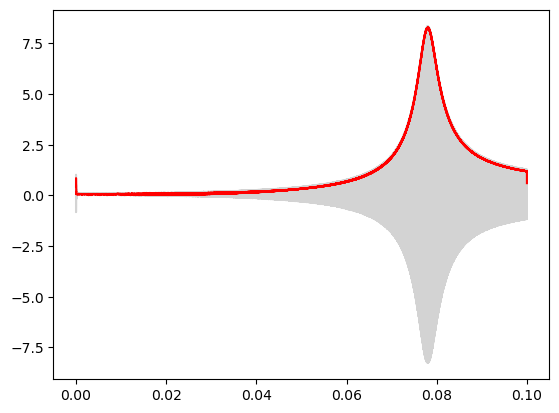

In [93]:
plt.plot(t,v, c='lightgrey')
plt.plot(t, v_amp, c='red')

Now you can make a Bode plot. Here is a starting point for your code. You can also make a function that does the Bode plot. You can even make a function that sets up the sweep, does the meaurement, converts it to dB, and then makes a plot :)

Text(0.5, 0, 'Frequency response (dB)')

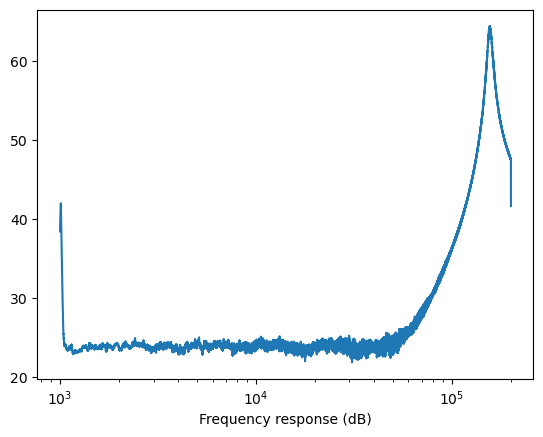

In [66]:
# For a Bode plot, convert this in dB relative the voltage
# applied on your generator

v_gen_ptp = 1
v_gen_amp = v_gen_ptp / 2

v_ratio = ...
dB = ...

plt.plot(f, dB)
plt.xscale("log")
plt.xlabel("Frequency response (dB)")
plt.xlabel("...")
plt.xlim(...,...) # you may want to zoom in a bit

theory = ...
plot.plot(f, theory)
...